# 01 — Data Generation & Schema Understanding

## Objective
Understand the structure, shape, and quality of the raw data
simulating ride cancellation behavior on a Bangalore ride
sharing platform.

## What This Notebook Covers
- Schema of each table
- Row counts and column types
- Null value analysis per table
- Duplicate detection
- Outlier identification
- Target variable (ride_outcome) class distribution
- Key observations before we touch any cleaning

## Data Period : Full Year 2025
## City        : Bangalore
## Tables      : rides, drivers, users, weather
## Target      : ride_outcome (3-class: completed / driver cancel / user cancel)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
DATA_PATH = "../data/raw/"

rides_df   = pd.read_csv(DATA_PATH + "rides.csv")
drivers_df = pd.read_csv(DATA_PATH + "drivers.csv")
users_df   = pd.read_csv(DATA_PATH + "users.csv")
weather_df = pd.read_csv(DATA_PATH + "weather.csv")

print("All tables loaded ✅")
print(f"  rides   : {rides_df.shape}")
print(f"  drivers : {drivers_df.shape}")
print(f"  users   : {users_df.shape}")
print(f"  weather : {weather_df.shape}")

All tables loaded ✅
  rides   : (60300, 34)
  drivers : (3000, 17)
  users   : (20200, 17)
  weather : (87600, 7)


## Table Relationships
rides ──────── drivers   (via driver_id)

rides ──────── users     (via user_id)

rides ──────── weather   (via pickup_zone + hour of ride_timestamp)

rides is the FACT TABLE. ride_outcome is our TARGET VARIABLE:
  0 = completed
  1 = cancelled by driver
  2 = cancelled by user

Unlike surge pricing (regression — predicting a number), this is
a CLASSIFICATION problem (predicting a category).

In [3]:
tables = {
    "rides"  : rides_df,
    "drivers": drivers_df,
    "users"  : users_df,
    "weather": weather_df,
}

for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f" TABLE: {name.upper()}  |  {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*55}")
    print(df.dtypes.to_string())


 TABLE: RIDES  |  60,300 rows × 34 columns
ride_id                             str
driver_id                           str
user_id                             str
pickup_zone                         str
drop_zone                           str
pickup_lat                      float64
pickup_lon                      float64
drop_lat                        float64
drop_lon                        float64
pickup_accuracy_score           float64
ride_timestamp                      str
hour                              int64
month                             int64
day_of_week                         str
is_weekend                         bool
is_holiday                         bool
vehicle_type                        str
weather_condition                   str
driver_distance_to_pickup_km    float64
driver_rating_at_booking        float64
driver_acceptance_rate          float64
driver_cancellations_today        int64
user_rating_at_booking          float64
user_cancellations_last_30d       in

## Section: Target Variable Deep Dive

This is the most important section in this notebook. Before
looking at any other column, we must deeply understand
ride_outcome — because every modeling decision later depends
on how balanced or imbalanced this target is.

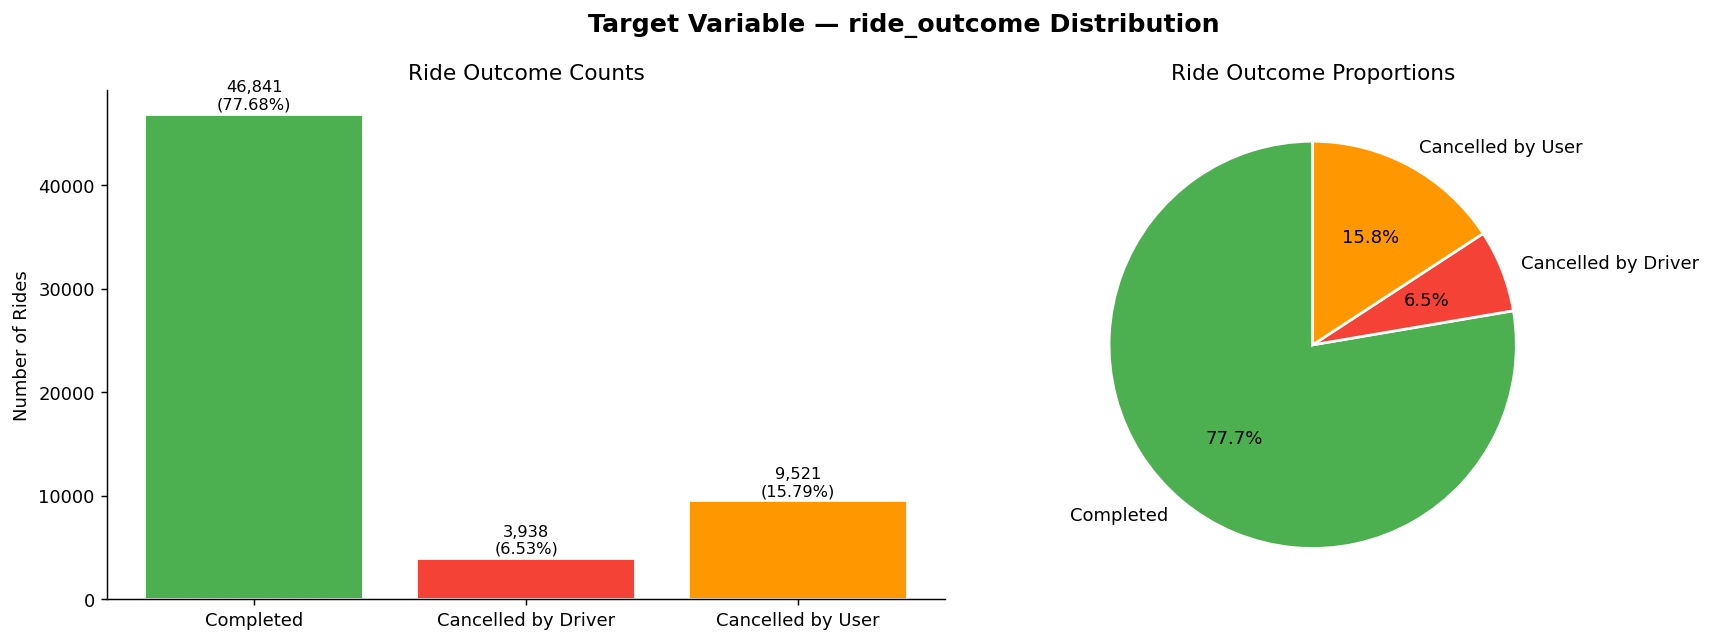

Class Distribution:
  Completed             :  46,841  (77.68%)
  Cancelled by Driver   :   3,938  (6.53%)
  Cancelled by User     :   9,521  (15.79%)

Imbalance Ratio (Completed : Driver Cancel : User Cancel)
  11.89 : 1 : 2.42


In [4]:
outcome_labels = {0: "Completed", 1: "Cancelled by Driver", 2: "Cancelled by User"}
rides_df["outcome_label"] = rides_df["ride_outcome"].map(outcome_labels)

counts = rides_df["ride_outcome"].value_counts().sort_index()
pcts   = (counts / len(rides_df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Variable — ride_outcome Distribution", fontsize=14, fontweight="bold")

colors = ["#4CAF50", "#F44336", "#FF9800"]

axes[0].bar(
    [outcome_labels[i] for i in counts.index],
    counts.values, color=colors, edgecolor="white"
)
axes[0].set_title("Ride Outcome Counts")
axes[0].set_ylabel("Number of Rides")
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, c + 500, f"{c:,}\n({p}%)", ha="center", fontsize=9)

axes[1].pie(
    counts.values, labels=[outcome_labels[i] for i in counts.index],
    autopct="%1.1f%%", colors=colors, startangle=90,
    wedgeprops={"edgecolor":"white", "linewidth":1.5}
)
axes[1].set_title("Ride Outcome Proportions")

plt.tight_layout()
plt.savefig("../data/raw/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Class Distribution:")
for k, v in counts.items():
    print(f"  {outcome_labels[k]:<22}: {v:>7,}  ({pcts[k]}%)")

print(f"\nImbalance Ratio (Completed : Driver Cancel : User Cancel)")
print(f"  {counts[0]/counts[1]:.2f} : 1 : {counts[2]/counts[1]:.2f}")

### Why This Class Imbalance Matters

A model that simply predicts "Completed" for every single ride
would be correct about 78% of the time — but completely useless,
because it would never identify a single cancellation.

This is called the "dummy classifier trap." Accuracy alone will
be misleading for this problem. We will need:
- Precision, Recall, F1-score (per class)
- Confusion matrix
- Possibly class weighting or resampling techniques (SMOTE)
  in the feature engineering / modeling notebooks

We note this here so it informs every decision going forward.

In [5]:
print("\n NULL VALUE SUMMARY PER TABLE\n")

for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    null_pct    = (null_counts / len(df) * 100).round(2)

    print(f"\n── {name.upper()} ──")
    if len(null_counts) == 0:
        print("  No nulls found")
    else:
        summary = pd.DataFrame({"null_count": null_counts, "null_%": null_pct})
        print(summary.to_string())


 NULL VALUE SUMMARY PER TABLE


── RIDES ──
                              null_count  null_%
pickup_zone                         1821    3.02
drop_zone                           1224    2.03
pickup_accuracy_score               1793    2.97
driver_distance_to_pickup_km         887    1.47
driver_rating_at_booking            1697    2.81
driver_acceptance_rate              2982    4.95
user_rating_at_booking              2539    4.21
estimated_wait_time_min             1231    2.04
distance_km                        13459   22.32
duration_min                       13459   22.32
fare_amount                        13459   22.32
time_to_cancellation_min           46841   77.68
cancelled_by                       46841   77.68
cancellation_reason                48563   80.54

── DRIVERS ──
                      null_count  null_%
phone                         58    1.93
vehicle_model                282    9.40
vehicle_year                 350   11.67
rating                        82    2.73


### Important Note on Nulls in Rides Table

Several columns in rides.csv are EXPECTED to be null depending
on the outcome:

- distance_km, duration_min, fare_amount → null when ride was
  CANCELLED (trip never happened, so there's nothing to measure)
- time_to_cancellation_min, cancelled_by, cancellation_reason →
  null when ride was COMPLETED (no cancellation occurred)

These are not data quality problems — they are structurally
correct nulls. We will verify this in the next cell.

In [6]:
print("Verifying structural null patterns by outcome:\n")

for outcome_val, label in outcome_labels.items():
    subset = rides_df[rides_df["ride_outcome"] == outcome_val]
    print(f"── {label} (n={len(subset):,}) ──")
    print(f"  distance_km null %    : {subset['distance_km'].isnull().mean()*100:.1f}%")
    print(f"  fare_amount null %    : {subset['fare_amount'].isnull().mean()*100:.1f}%")
    print(f"  cancelled_by null %   : {subset['cancelled_by'].isnull().mean()*100:.1f}%")
    print(f"  cancellation_reason % : {subset['cancellation_reason'].isnull().mean()*100:.1f}%")
    print()

Verifying structural null patterns by outcome:

── Completed (n=46,841) ──
  distance_km null %    : 0.0%
  fare_amount null %    : 0.0%
  cancelled_by null %   : 100.0%
  cancellation_reason % : 100.0%

── Cancelled by Driver (n=3,938) ──
  distance_km null %    : 100.0%
  fare_amount null %    : 100.0%
  cancelled_by null %   : 0.0%
  cancellation_reason % : 14.0%

── Cancelled by User (n=9,521) ──
  distance_km null %    : 100.0%
  fare_amount null %    : 100.0%
  cancelled_by null %   : 0.0%
  cancellation_reason % : 12.3%



In [7]:
print("\n DUPLICATE ROW DETECTION\n")

for name, df in tables.items():
    dupe_count = df.duplicated().sum()
    pct        = round(dupe_count / len(df) * 100, 3)
    print(f"  {name:<10}: {dupe_count:>5} duplicates  ({pct}%)")


 DUPLICATE ROW DETECTION

  rides     :   300 duplicates  (0.498%)
  drivers   :     0 duplicates  (0.0%)
  users     :   200 duplicates  (0.99%)
  weather   :     0 duplicates  (0.0%)


In [8]:
print("RIDES TABLE — First 5 rows")
rides_df.head()

RIDES TABLE — First 5 rows


,ride_id,driver_id,user_id,pickup_zone,drop_zone,pickup_lat,pickup_lon,drop_lat,drop_lon,pickup_accuracy_score,ride_timestamp,hour,month,day_of_week,is_weekend,is_holiday,vehicle_type,weather_condition,driver_distance_to_pickup_km,driver_rating_at_booking,driver_acceptance_rate,driver_cancellations_today,user_rating_at_booking,user_cancellations_last_30d,user_booking_attempts,estimated_wait_time_min,surge_at_booking,distance_km,duration_min,fare_amount,time_to_cancellation_min,cancelled_by,cancellation_reason,ride_outcome,outcome_label
0,RID0053168,DRV00951,USR014460,Koramangala,Whitefield,12.93,77.62,12.99,77.76,0.94,2025-11-05 16:10:56,16,11,Wednesday,False,True,Auto,Storm,2.33,4.46,0.61,0,3.90,2,1,NaN,2.10,NaN,NaN,NaN,4.70,driver,NaN,1,Cancelled by Driver
1,RID0046548,DRV01480,USR015231,Whitefield,Malleswaram,12.96,77.75,13.00,77.58,0.46,2025-10-14 23:50:24,23,10,Tuesday,False,False,Sedan,Light Rain,2.77,4.68,0.75,0,4.20,2,1,9.20,1.40,NaN,NaN,NaN,11.00,user,Surge price too high,2,Cancelled by User
2,RID0034406,DRV01459,USR016009,Hebbal,Indiranagar,13.04,77.59,12.98,77.65,0.88,2025-06-03 15:37:32,15,6,Tuesday,False,False,Auto,Clear,4.68,4.34,0.92,0,4.00,0,1,14.50,1.00,5.48,27.80,95.76,NaN,NaN,NaN,0,Completed
3,RID0025415,DRV00145,USR002787,Whitefield,Bellandur,12.98,77.75,12.93,77.67,0.85,2025-08-18 23:32:36,23,8,Monday,False,False,Sedan,Clear,5.77,4.37,0.73,0,3.80,1,2,17.50,1.00,NaN,NaN,NaN,1.30,driver,User unresponsive,1,Cancelled by Driver
4,RID0057278,DRV01632,USR005271,Bannerghatta Road,Kadugodi,12.86,77.60,12.98,77.76,0.66,2025-07-04 10:50:46,10,7,Friday,False,False,Auto,Foggy,2.18,4.27,0.92,0,4.80,1,3,10.90,1.40,12.58,51.70,253.34,NaN,NaN,NaN,0,Completed


In [9]:
print("OUTLIER CHECK — Key Numerical Columns\n")

num_cols = [
    "driver_distance_to_pickup_km", "estimated_wait_time_min",
    "surge_at_booking", "distance_km", "duration_min", "fare_amount",
    "driver_cancellations_today", "user_cancellations_last_30d",
    "user_booking_attempts"
]

for col in num_cols:
    col_data = rides_df[col].dropna()
    print(f"  {col:<32} min={col_data.min():>8.2f}  max={col_data.max():>8.2f}  "
          f"mean={col_data.mean():>7.2f}  negatives={(col_data < 0).sum()}")

OUTLIER CHECK — Key Numerical Columns

  driver_distance_to_pickup_km     min=    0.20  max=   15.00  mean=   2.51  negatives=0
  estimated_wait_time_min          min=   -0.40  max=  145.30  mean=  10.99  negatives=313
  surge_at_booking                 min=    1.00  max=    3.20  mean=   1.37  negatives=0
  distance_km                      min=    0.50  max=   45.00  mean=   6.01  negatives=0
  duration_min                     min=    1.50  max=  265.80  mean=  26.99  negatives=0
  fare_amount                      min=   36.00  max= 1235.52  mean= 138.42  negatives=0
  driver_cancellations_today       min=    0.00  max=    1.00  mean=   0.00  negatives=0
  user_cancellations_last_30d      min=    0.00  max=   12.00  mean=   1.93  negatives=0
  user_booking_attempts            min=    1.00  max=    6.00  mean=   2.13  negatives=0


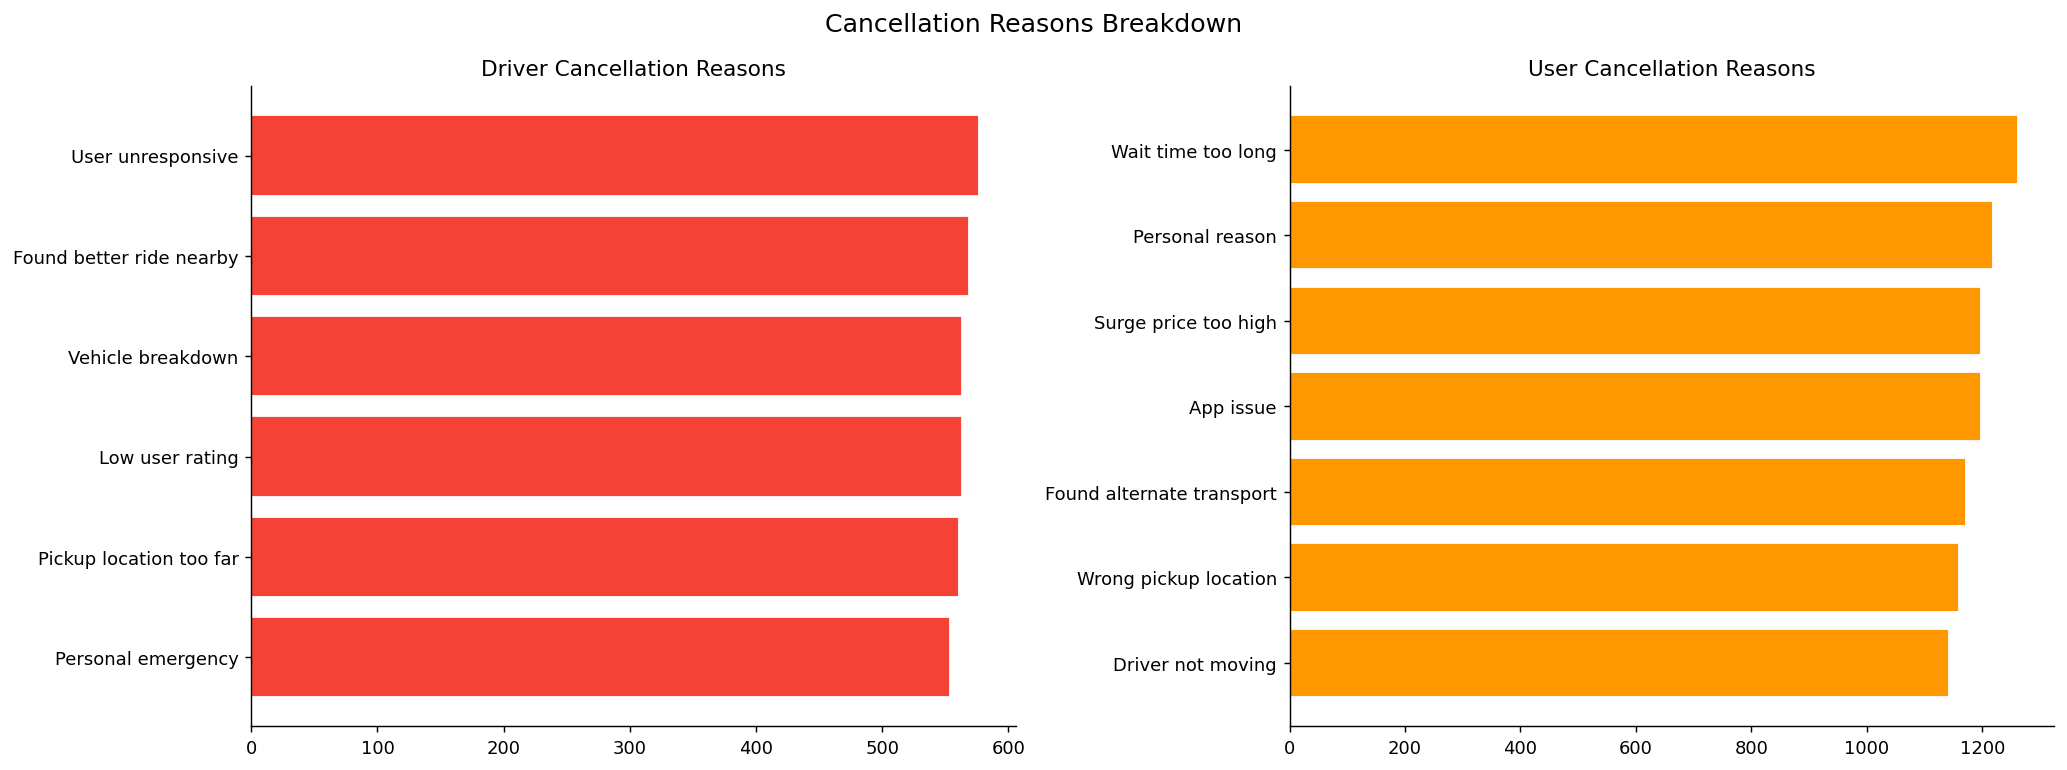

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cancellation Reasons Breakdown", fontsize=14)

driver_reasons = rides_df[rides_df["ride_outcome"]==1]["cancellation_reason"].value_counts()
user_reasons   = rides_df[rides_df["ride_outcome"]==2]["cancellation_reason"].value_counts()

axes[0].barh(driver_reasons.index, driver_reasons.values, color="#F44336", edgecolor="white")
axes[0].set_title("Driver Cancellation Reasons")
axes[0].invert_yaxis()

axes[1].barh(user_reasons.index, user_reasons.values, color="#FF9800", edgecolor="white")
axes[1].set_title("User Cancellation Reasons")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/raw/cancellation_reasons.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Observations from Raw Data

### Target Variable
- Completed: 77.7%, User Cancel: 15.8%, Driver Cancel: 6.5%
- This is an imbalanced 3-class problem — accuracy alone
  will be a misleading metric
- Driver cancellation is the rarest class — will be hardest
  for the model to learn and likely needs special attention
  (class weights or resampling)

### Nulls
- Most nulls are structural (expected based on ride outcome)
  not data quality problems
- True data quality nulls exist in phone/email/rating columns —
  similar pattern to surge pricing project

### Duplicates
- Small percentage of duplicate users/drivers/rides — simulates
  system glitches, same approach as surge pricing

### What This Means for Next Steps
- Cleaning notebook must distinguish structural nulls (keep as
  meaningful) from data quality nulls (impute or flag)
- Feature engineering must NOT use any column that is only
  available AFTER the ride starts/ends (like fare_amount,
  duration_min) — these would leak the answer, since we need
  to predict cancellation BEFORE it happens, using only
  information available AT BOOKING TIME

## ⚠️ Critical Note — Data Leakage Risk

This is a NEW concept that didn't apply to surge pricing.

In a real production system, we would predict ride_outcome
THE MOMENT a ride is booked — before we know whether it will
complete or get cancelled. This means we can ONLY use features
that exist AT BOOKING TIME.

Columns we MUST NOT use as features (they only exist AFTER
the outcome is known):
- distance_km, duration_min, fare_amount (trip details — only
  exist for completed rides — using them would let the model
  "cheat" by seeing the answer)
- time_to_cancellation_min, cancelled_by, cancellation_reason
  (literally describe the cancellation itself)

Columns we CAN use (available at booking time):
- driver_distance_to_pickup_km, driver_rating_at_booking,
  driver_acceptance_rate, driver_cancellations_today
- user_rating_at_booking, user_cancellations_last_30d,
  user_booking_attempts
- estimated_wait_time_min, surge_at_booking
- hour, day_of_week, is_weekend, is_holiday, weather_condition
- pickup_zone, drop_zone, vehicle_type

We will enforce this strictly in the feature engineering notebook.

In [11]:
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : len(df.columns),
        "null_cells" : df.isnull().sum().sum(),
        "duplicates" : df.duplicated().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n FINAL DATA SUMMARY\n")
print(summary_df.to_string(index=False))


 FINAL DATA SUMMARY

  table  rows  columns  null_cells  duplicates
  rides 60300       35      196796         300
drivers  3000       17        1034           0
  users 20200       17       14437         200
weather 87600        7        3544           0
